In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sources = pd.read_csv("ovro_sources.txt", sep=r"\s+")
sources.head()

,Number,Source_Name,Right_Ascension,Declination
0,1,J0001-1551,00:01:05.328,-15:51:06.840
1,2,J0001+1914,00:01:08.616,19:14:33.000
2,3,CRJ0001-0746,00:01:18.024,-7:46:27.120
3,4,J0003+2129,00:03:19.344,21:29:44.160
4,5,J0004-1148,00:04:04.920,-11:48:57.960


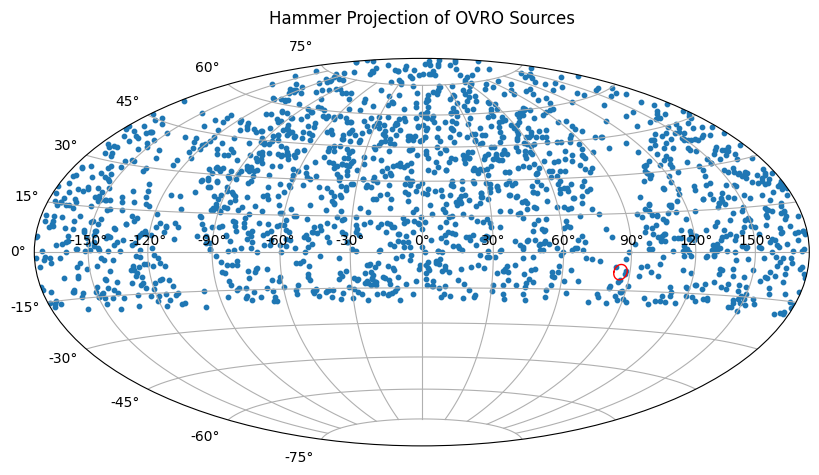

In [43]:
def ra_to_degrees(ra):
    h, m, s = ra.split(":")
    h = float(h)
    m = float(m)
    s = float(s)

    return 15 * (h + m / 60 + s / 3600)


def dec_to_degrees(dec):
    sign = -1 if dec.startswith("-") else 1

    dec = dec.replace("+", "").replace("-", "")
    d, m, s = dec.split(":")

    d = float(d)
    m = float(m)
    s = float(s)

    return sign * (d + m / 60 + s / 3600)

sources["RA_deg"] = sources["Right_Ascension"].apply(ra_to_degrees)
sources["Dec_deg"] = sources["Declination"].apply(dec_to_degrees)

sources.head()


ra_plot_deg = 180 - sources["RA_deg"]

ra_rad = np.radians(ra_plot_deg)
dec_rad = np.radians(sources["Dec_deg"])

plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection="hammer")

ax.scatter(ra_rad, dec_rad, s=10)

# Circle: radius 3 degrees centered at RA = 94.3 deg, Dec = -7.8 deg
center_ra_deg = 94.3
center_dec_deg = -7.8
radius_deg = 3

theta = np.linspace(0, 2 * np.pi, 300)

circle_ra_deg = center_ra_deg + radius_deg * np.cos(theta) / np.cos(np.radians(center_dec_deg))
circle_dec_deg = center_dec_deg + radius_deg * np.sin(theta)

circle_ra_plot_deg = 180 - circle_ra_deg

circle_ra_rad = np.radians(circle_ra_plot_deg)
circle_dec_rad = np.radians(circle_dec_deg)

ax.plot(circle_ra_rad, circle_dec_rad, color="red", linewidth=1)

ax.grid(True)
ax.set_title("Hammer Projection of OVRO Sources", pad=25)

plt.show()

In [42]:
center_ra_deg = 94.3
center_dec_deg = -7.8
radius_deg = 3

ra1 = np.radians(sources["RA_deg"])
dec1 = np.radians(sources["Dec_deg"])

ra2 = np.radians(center_ra_deg)
dec2 = np.radians(center_dec_deg)

# Angular separation formula on a sphere
cos_sep = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2)
)

# Small numerical errors can make cos_sep slightly bigger than 1 or smaller than -1
cos_sep = np.clip(cos_sep, -1, 1)

separation_deg = np.degrees(np.arccos(cos_sep))

sources["Separation_deg"] = separation_deg

inside_circle = sources[sources["Separation_deg"] <= radius_deg]

inside_circle

,Number,Source_Name,Right_Ascension,Declination,RA_deg,Dec_deg,Separation_deg
429,430,J0606-0724,06:06:43.560,-7:24:29.880,91.6815,-7.4083,2.624854
433,434,J0607-0834,06:07:59.712,-8:34:50.160,91.9988,-8.5806,2.407755
440,441,J0616-1041,06:16:41.808,-10:41:08.160,94.1742,-10.6856,2.888270
